In [1]:
"""05_validation.ipynb

# 05 — Cross-Stream Validation

**What this notebook does**: tests ANY generative model's synthetic log-signatures
against the real data using 7 standardised metrics. Run once per model, changing
only MODEL_NAME and the input file paths.

**Design principle**: this notebook is a CONSUMER, not a PRODUCER. It reads
synthetic parquet files, computes metrics against real data, and writes a
JSON report. It does not train anything.

**Inputs** (parameterised per model):
- Real log-signatures parquet
- Synthetic log-signatures parquet

**Output**: `data/validation_{MODEL_NAME}.json`
"""

%pip install -q polars pyarrow matplotlib numpy scipy scikit-learn iisignature statsmodels

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
print(f"Data directory: {DATA_DIR}")

import json
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from collections import Counter

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

# ════════════════════════════════════════════════════════════════════════════════
# CELL 1 — Configuration: CHANGE THESE FOR EACH MODEL
# ════════════════════════════════════════════════════════════════════════════════
# Run this notebook once per model. Only change this cell.

MODEL_NAME  = "cvae_s2"                                   # or "cvae_s1", "sigcwgan", "neural_sde"
REAL_FILE   = DATA_DIR / "logsigs_s2.parquet"             # or "logsigs.parquet" for s1
SYNTH_FILE  = DATA_DIR / "cvae_generated_logsigs_s2.parquet"
OUTPUT_JSON = DATA_DIR / f"validation_{MODEL_NAME}.json"

print(f"Model:     {MODEL_NAME}")
print(f"Real:      {REAL_FILE.name}")
print(f"Synthetic: {SYNTH_FILE.name}")
print(f"Output:    {OUTPUT_JSON.name}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounted at /content/drive
Data directory: /content/drive/MyDrive/energy_synthetic_data/data
Model:     cvae_s2
Real:      logsigs_s2.parquet
Synthetic: cvae_generated_logsigs_s2.parquet
Output:    validation_cvae_s2.json


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 2 — Load data
# ════════════════════════════════════════════════════════════════════════════════

df_real  = pl.read_parquet(REAL_FILE)
df_synth = pl.read_parquet(SYNTH_FILE)

ls_cols_real  = sorted([c for c in df_real.columns  if c.startswith("ls_")])
ls_cols_synth = sorted([c for c in df_synth.columns if c.startswith("ls_")])

# Use intersection of columns (some models may drop zero-variance dims)
ls_cols = sorted(set(ls_cols_real) & set(ls_cols_synth))
print(f"Common log-sig dims: {len(ls_cols)}")

X_real  = df_real.select(ls_cols).to_numpy().astype(np.float64)
X_synth = df_synth.select(ls_cols).to_numpy().astype(np.float64)

regimes_real  = df_real["regime"].to_list()  if "regime" in df_real.columns  else ["unknown"] * len(X_real)
regimes_synth = df_synth["regime"].to_list() if "regime" in df_synth.columns else ["unknown"] * len(X_synth)

print(f"Real:      {X_real.shape}")
print(f"Synthetic: {X_synth.shape}")
print(f"Real regimes:  {Counter(regimes_real)}")
print(f"Synth regimes: {Counter(regimes_synth)}")


Common log-sig dims: 89
Real:      (6530, 89)
Synthetic: (10000, 89)
Real regimes:  Counter({'calm': 1963, 'spike': 1940, 'volatile': 1827, 'negative': 800})
Synth regimes: Counter({'volatile': 3000, 'calm': 3000, 'spike': 2500, 'negative': 1500})


TEST 1: Marginal distribution matching (per log-sig dimension)
  Mean Wasserstein-1: 1.3233
  Mean KS statistic: 0.0651
  Worst 5 dims by W1:
  dim  wasserstein_1  ks_stat
ls_84      18.585496 0.181484
ls_74      12.556353 0.160685
ls_82       9.390881 0.188727
ls_85       9.339214 0.181966
ls_72       9.220659 0.162180


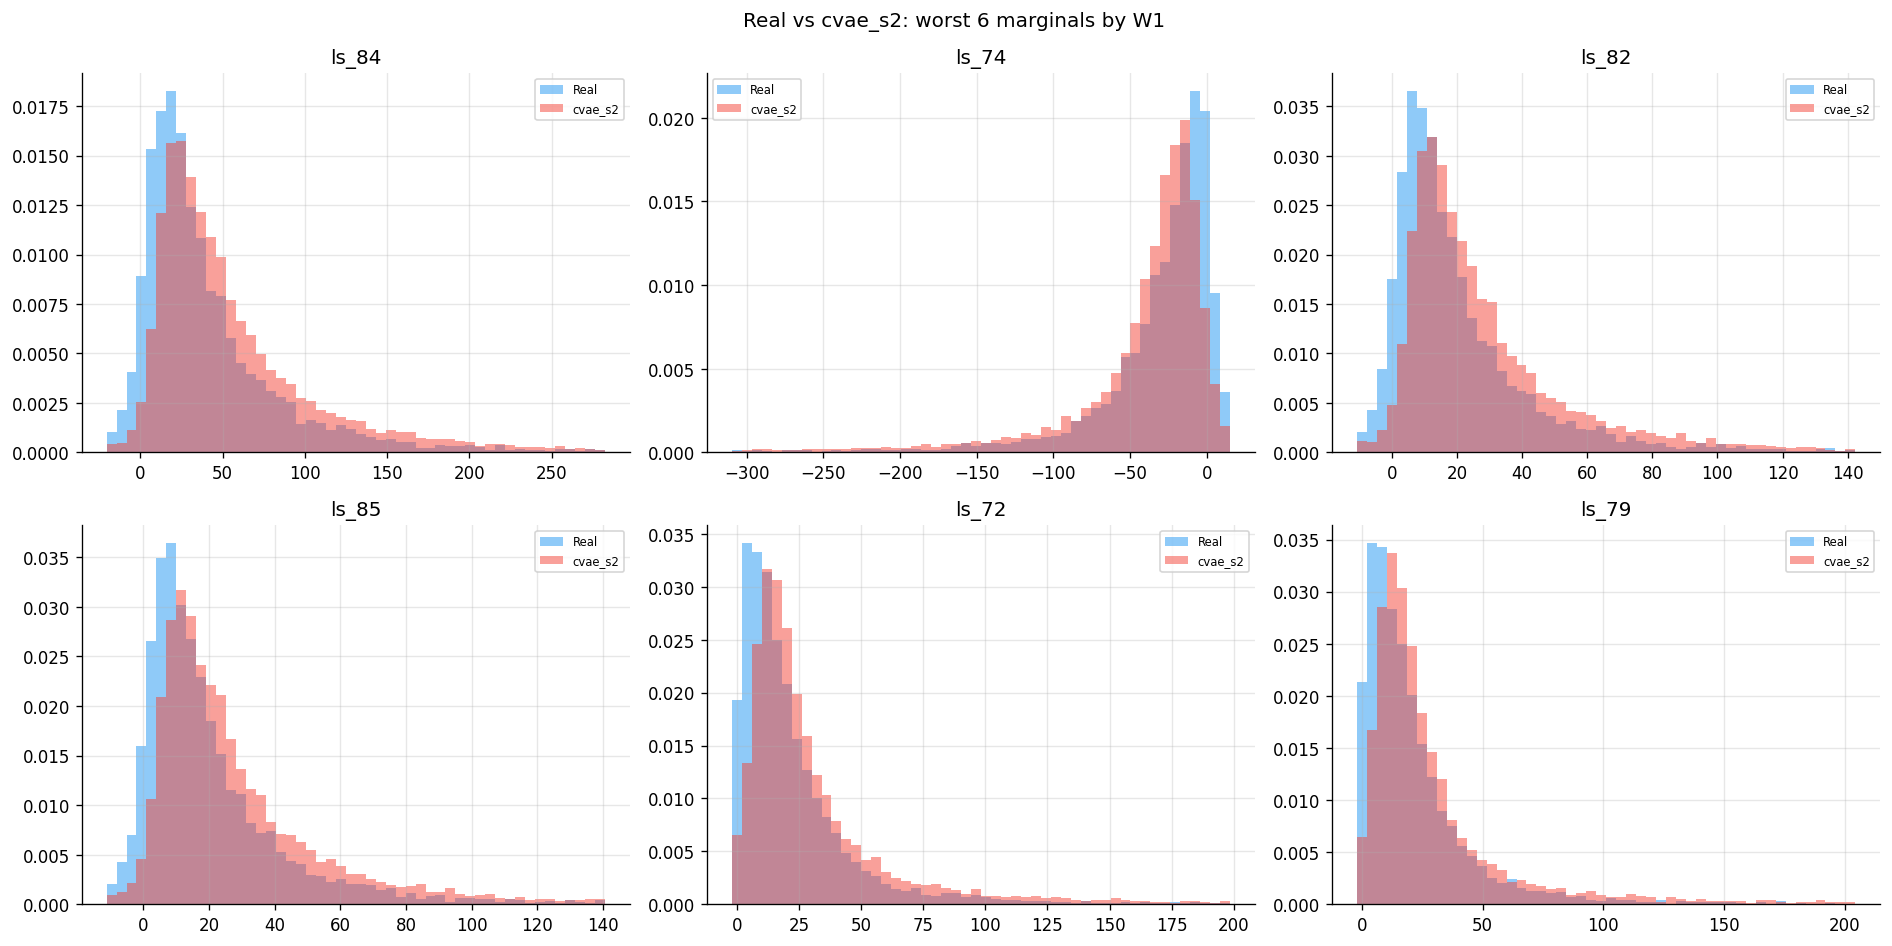

In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 3 — Test 1: Marginal distribution matching
# ════════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("TEST 1: Marginal distribution matching (per log-sig dimension)")
print("=" * 60)

from scipy.stats import wasserstein_distance, ks_2samp

marginal_results = []
for i, col in enumerate(ls_cols):
    r = X_real[:, i]
    s = X_synth[:, i]
    w1   = wasserstein_distance(r, s)
    ks_s, ks_p = ks_2samp(r, s)
    marginal_results.append({
        "dim": col, "wasserstein_1": w1,
        "ks_stat": ks_s, "ks_pval": ks_p,
        "mean_real": float(r.mean()), "mean_synth": float(s.mean()),
        "std_real":  float(r.std()),  "std_synth":  float(s.std()),
        "skew_real": float(stats.skew(r)), "skew_synth": float(stats.skew(s)),
        "kurt_real": float(stats.kurtosis(r)), "kurt_synth": float(stats.kurtosis(s)),
    })

df_marg = pd.DataFrame(marginal_results)
mean_w1 = df_marg["wasserstein_1"].mean()
mean_ks = df_marg["ks_stat"].mean()
print(f"  Mean Wasserstein-1: {mean_w1:.4f}")
print(f"  Mean KS statistic: {mean_ks:.4f}")
print(f"  Worst 5 dims by W1:")
print(df_marg.nlargest(5, "wasserstein_1")[["dim","wasserstein_1","ks_stat"]].to_string(index=False))

# Plot worst 6 dims
worst6 = df_marg.nlargest(6, "wasserstein_1")["dim"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f"Real vs {MODEL_NAME}: worst 6 marginals by W1")
for ax, col in zip(axes.flat, worst6):
    i = ls_cols.index(col)
    lo, hi = np.percentile(X_real[:, i], [1, 99])
    ax.hist(X_real[:, i],  bins=50, density=True, alpha=0.5, color="#2196F3", label="Real", range=(lo,hi))
    ax.hist(X_synth[:, i], bins=50, density=True, alpha=0.5, color="#F44336", label=MODEL_NAME, range=(lo,hi))
    ax.set_title(col); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(DATA_DIR / f"05_{MODEL_NAME}_marginals.png", bbox_inches="tight")
plt.show()



TEST 2: Correlation structure
  Frobenius norm of correlation difference: 5.5553
  Max absolute pairwise correlation error:  0.2613


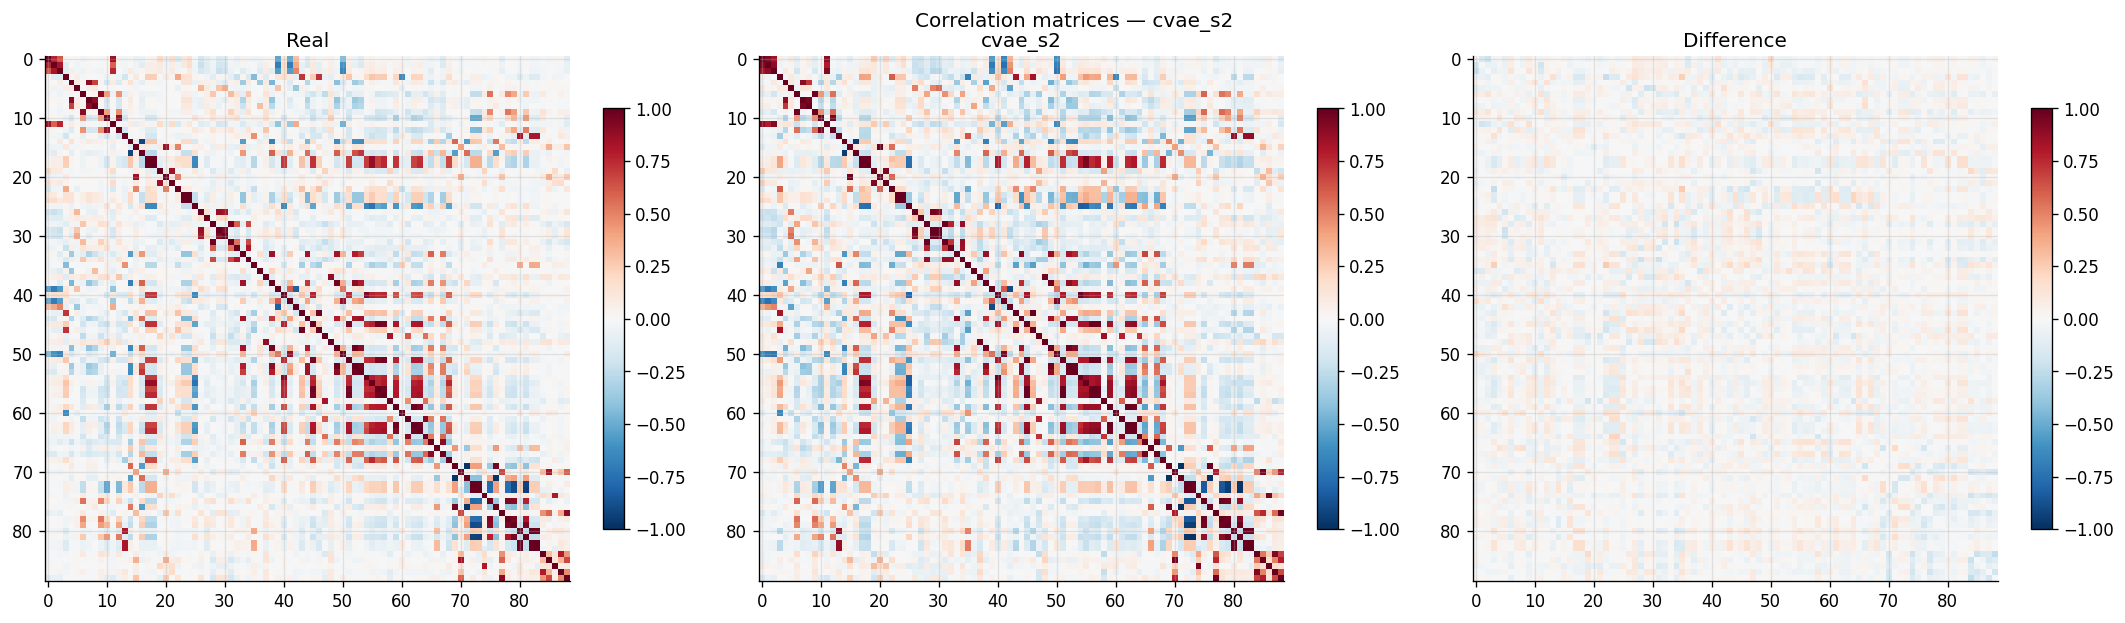

In [4]:

# ════════════════════════════════════════════════════════════════════════════════
# CELL 4 — Test 2: Correlation structure
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TEST 2: Correlation structure")
print("=" * 60)

corr_real  = np.corrcoef(X_real.T)
corr_synth = np.corrcoef(X_synth.T)
corr_diff  = corr_real - corr_synth
frob_norm  = np.linalg.norm(corr_diff, "fro")
max_diff   = np.max(np.abs(corr_diff))

print(f"  Frobenius norm of correlation difference: {frob_norm:.4f}")
print(f"  Max absolute pairwise correlation error:  {max_diff:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mat, title in zip(axes, [corr_real, corr_synth, corr_diff],
                           ["Real", MODEL_NAME, "Difference"]):
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(title); plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle(f"Correlation matrices — {MODEL_NAME}")
plt.tight_layout()
plt.savefig(DATA_DIR / f"05_{MODEL_NAME}_corr.png", bbox_inches="tight")
plt.show()


In [5]:

# ════════════════════════════════════════════════════════════════════════════════
# CELL 5 — Test 3: Regime-conditional quality
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TEST 3: Regime-conditional Wasserstein-1")
print("=" * 60)

regime_w1 = {}
for regime in ["calm", "volatile", "spike", "negative"]:
    mask_r = np.array([r == regime for r in regimes_real])
    mask_s = np.array([r == regime for r in regimes_synth])
    if mask_r.sum() < 20 or mask_s.sum() < 20:
        print(f"  {regime}: insufficient samples (real={mask_r.sum()}, synth={mask_s.sum()})")
        regime_w1[regime] = float("nan")
        continue
    w1s = [wasserstein_distance(X_real[mask_r, j], X_synth[mask_s, j])
           for j in range(X_real.shape[1])]
    regime_w1[regime] = float(np.mean(w1s))
    print(f"  {regime:10s}: mean W1 = {regime_w1[regime]:.4f}  "
          f"(n_real={mask_r.sum()}, n_synth={mask_s.sum()})")

worst_regime = max(regime_w1, key=lambda k: regime_w1[k] if not np.isnan(regime_w1[k]) else -1)
print(f"  Worst regime: {worst_regime}")



TEST 3: Regime-conditional Wasserstein-1
  calm      : mean W1 = 1.2096  (n_real=1963, n_synth=3000)
  volatile  : mean W1 = 1.1366  (n_real=1827, n_synth=3000)
  spike     : mean W1 = 2.1353  (n_real=1940, n_synth=2500)
  negative  : mean W1 = 2.2891  (n_real=800, n_synth=1500)
  Worst regime: negative



TEST 4: Lévy area (|ls_7|) distribution
  W1(|ls_7|):       2.5820
  KS stat:          0.1425  (p=2.04e-70)
  Real 95th pct:    47.7350
  Tail mass (real): 0.050
  Tail mass (synth):0.026  (OK)


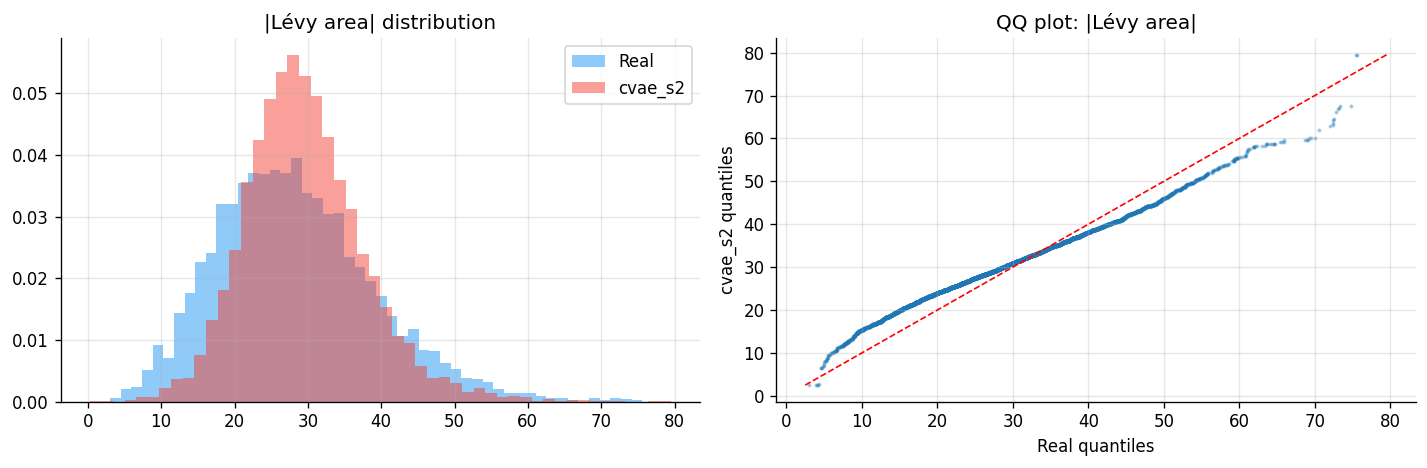

In [6]:

# ════════════════════════════════════════════════════════════════════════════════
# CELL 6 — Test 4: Lévy area distribution
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TEST 4: Lévy area (|ls_7|) distribution")
print("=" * 60)

LEVY_COL = "ls_7"
if LEVY_COL in ls_cols:
    idx_levy = ls_cols.index(LEVY_COL)
    levy_real  = np.abs(X_real[:, idx_levy])
    levy_synth = np.abs(X_synth[:, idx_levy])

    w1_levy = wasserstein_distance(levy_real, levy_synth)
    ks_levy, ks_p_levy = ks_2samp(levy_real, levy_synth)
    pct95_real  = np.percentile(levy_real, 95)
    tail_real   = (levy_real  > pct95_real).mean()
    tail_synth  = (levy_synth > pct95_real).mean()

    print(f"  W1(|ls_7|):       {w1_levy:.4f}")
    print(f"  KS stat:          {ks_levy:.4f}  (p={ks_p_levy:.2e})")
    print(f"  Real 95th pct:    {pct95_real:.4f}")
    print(f"  Tail mass (real): {tail_real:.3f}")
    print(f"  Tail mass (synth):{tail_synth:.3f}  "
          f"({'OK' if abs(tail_synth - tail_real) < 0.03 else 'UNDER-GENERATES TAILS'})")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(levy_real,  bins=50, density=True, alpha=0.5, color="#2196F3", label="Real")
    axes[0].hist(levy_synth, bins=50, density=True, alpha=0.5, color="#F44336", label=MODEL_NAME)
    axes[0].set_title("|Lévy area| distribution"); axes[0].legend()

    qq_real  = np.sort(levy_real)
    qq_synth = np.sort(np.random.choice(levy_synth, len(levy_real), replace=True))
    axes[1].scatter(qq_real, qq_synth, s=2, alpha=0.3)
    mn, mx = min(qq_real.min(), qq_synth.min()), max(qq_real.max(), qq_synth.max())
    axes[1].plot([mn, mx], [mn, mx], "r--", lw=1)
    axes[1].set_xlabel("Real quantiles"); axes[1].set_ylabel(f"{MODEL_NAME} quantiles")
    axes[1].set_title("QQ plot: |Lévy area|")
    plt.tight_layout()
    plt.savefig(DATA_DIR / f"05_{MODEL_NAME}_levy.png", bbox_inches="tight")
    plt.show()
else:
    w1_levy = ks_levy = tail_synth = float("nan")
    print(f"  {LEVY_COL} not in common columns — skipping")



TEST 5: Autocorrelation of segment-level statistics
  ACF error (returns proxy, lags 1-10): 0.0906
  ACF error (vol proxy,    lags 1-10): 0.1603
  Note: CVAE is expected to fail here (iid z → no temporal chain)


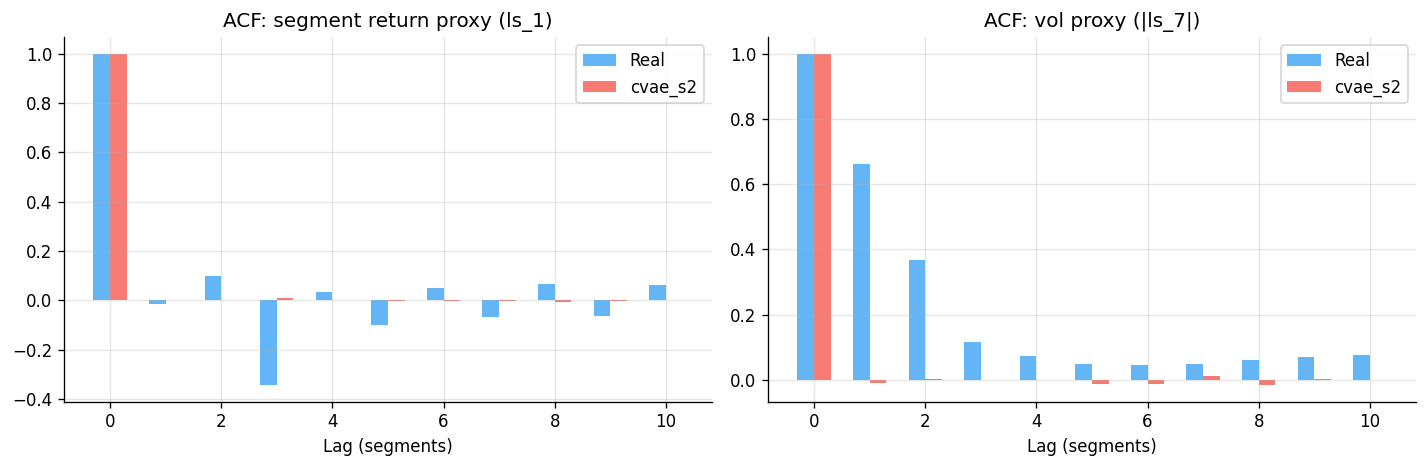

In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 7 — Test 5: Autocorrelation reproduction
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TEST 5: Autocorrelation of segment-level statistics")
print("=" * 60)

from statsmodels.tsa.stattools import acf

# Segment-mean return proxy: ls_1 (net price move) for temporally-ordered real data
if "ls_1" in ls_cols:
    idx_ret = ls_cols.index("ls_1")

    # Real ACF (temporally ordered)
    real_ret  = X_real[:, idx_ret]
    acf_real  = acf(real_ret, nlags=10, fft=True)

    # Synthetic ACF (no temporal order — shuffle and compute as baseline)
    synth_ret = X_synth[:, idx_ret]
    acf_synth = acf(synth_ret, nlags=10, fft=True)

    # RV proxy: |ls_7|
    if LEVY_COL in ls_cols:
        rv_real  = np.abs(X_real[:, ls_cols.index(LEVY_COL)])
        rv_synth = np.abs(X_synth[:, ls_cols.index(LEVY_COL)])
        acf_rv_real  = acf(rv_real,  nlags=10, fft=True)
        acf_rv_synth = acf(rv_synth, nlags=10, fft=True)
    else:
        acf_rv_real = acf_rv_synth = np.zeros(11)

    acf_ret_error = float(np.mean(np.abs(acf_real[1:] - acf_synth[1:])))
    acf_rv_error  = float(np.mean(np.abs(acf_rv_real[1:] - acf_rv_synth[1:])))

    print(f"  ACF error (returns proxy, lags 1-10): {acf_ret_error:.4f}")
    print(f"  ACF error (vol proxy,    lags 1-10): {acf_rv_error:.4f}")
    print("  Note: CVAE is expected to fail here (iid z → no temporal chain)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    lags = np.arange(11)
    axes[0].bar(lags - 0.15, acf_real,  width=0.3, color="#2196F3", label="Real", alpha=0.7)
    axes[0].bar(lags + 0.15, acf_synth, width=0.3, color="#F44336", label=MODEL_NAME, alpha=0.7)
    axes[0].set_title("ACF: segment return proxy (ls_1)"); axes[0].legend()
    axes[0].set_xlabel("Lag (segments)")

    axes[1].bar(lags - 0.15, acf_rv_real,  width=0.3, color="#2196F3", label="Real", alpha=0.7)
    axes[1].bar(lags + 0.15, acf_rv_synth, width=0.3, color="#F44336", label=MODEL_NAME, alpha=0.7)
    axes[1].set_title("ACF: vol proxy (|ls_7|)"); axes[1].legend()
    axes[1].set_xlabel("Lag (segments)")

    plt.tight_layout()
    plt.savefig(DATA_DIR / f"05_{MODEL_NAME}_acf.png", bbox_inches="tight")
    plt.show()
else:
    acf_ret_error = acf_rv_error = float("nan")


In [8]:

# ════════════════════════════════════════════════════════════════════════════════
# CELL 8 — Test 6: Stylised facts checklist
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TEST 6: Stylised facts checklist")
print("=" * 60)

facts = {}

# Heavy tails (kurtosis > 5 in at least half of dims)
kurt_synth = [stats.kurtosis(X_synth[:, j]) for j in range(X_synth.shape[1])]
facts["heavy_tails"] = sum(k > 5 for k in kurt_synth) > len(kurt_synth) / 2
print(f"  Heavy tails (kurtosis>5 in >50% dims):  {'PASS' if facts['heavy_tails'] else 'FAIL'}")

# Negative skew in return proxy
if "ls_1" in ls_cols:
    skew_synth = stats.skew(X_synth[:, ls_cols.index("ls_1")])
    facts["negative_skew"] = skew_synth < 0
    print(f"  Negative skew in return proxy:          {'PASS' if facts['negative_skew'] else 'FAIL'} (skew={skew_synth:.3f})")

# Spike frequency within 50% of real
spike_frac_real  = Counter(regimes_real).get("spike", 0)  / len(regimes_real)
spike_frac_synth = Counter(regimes_synth).get("spike", 0) / len(regimes_synth)
facts["spike_freq"] = abs(spike_frac_synth - spike_frac_real) < 0.5 * spike_frac_real if spike_frac_real > 0 else True
print(f"  Spike frequency match:                  {'PASS' if facts['spike_freq'] else 'FAIL'} "
      f"(real={spike_frac_real:.3f}, synth={spike_frac_synth:.3f})")

# Negative-price frequency
neg_frac_real  = Counter(regimes_real).get("negative", 0)  / len(regimes_real)
neg_frac_synth = Counter(regimes_synth).get("negative", 0) / len(regimes_synth)
facts["neg_freq"] = abs(neg_frac_synth - neg_frac_real) < 0.5 * neg_frac_real if neg_frac_real > 0 else True
print(f"  Negative-price frequency match:         {'PASS' if facts['neg_freq'] else 'FAIL'} "
      f"(real={neg_frac_real:.3f}, synth={neg_frac_synth:.3f})")

n_pass = sum(facts.values())
n_total = len(facts)
print(f"\n  Stylised facts: {n_pass}/{n_total} passed")



TEST 6: Stylised facts checklist
  Heavy tails (kurtosis>5 in >50% dims):  PASS
  Negative skew in return proxy:          PASS (skew=-0.025)
  Spike frequency match:                  PASS (real=0.297, synth=0.250)
  Negative-price frequency match:         PASS (real=0.123, synth=0.150)

  Stylised facts: 4/4 passed


In [9]:

# ════════════════════════════════════════════════════════════════════════════════
# CELL 9 — Test 7: Signature MMD two-sample test
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TEST 7: Signature-based MMD two-sample test")
print("=" * 60)

# Subsample for computational tractability
N_MMD = min(1000, len(X_real), len(X_synth))
np.random.seed(42)
idx_r = np.random.choice(len(X_real),  N_MMD, replace=False)
idx_s = np.random.choice(len(X_synth), N_MMD, replace=False)
Xr = X_real[idx_r]
Xs = X_synth[idx_s]

# Standardise jointly
mu  = Xr.mean(axis=0)
std = Xr.std(axis=0); std[std < 1e-8] = 1.0
Xr_n = (Xr - mu) / std
Xs_n = (Xs - mu) / std

# RBF kernel MMD
gamma = 1.0 / Xr_n.shape[1]
K_rr = rbf_kernel(Xr_n, Xr_n, gamma=gamma)
K_ss = rbf_kernel(Xs_n, Xs_n, gamma=gamma)
K_rs = rbf_kernel(Xr_n, Xs_n, gamma=gamma)

# Unbiased MMD² estimate
n = N_MMD
np.fill_diagonal(K_rr, 0)
np.fill_diagonal(K_ss, 0)
mmd2 = K_rr.sum()/(n*(n-1)) + K_ss.sum()/(n*(n-1)) - 2*K_rs.mean()
mmd  = float(np.sqrt(max(mmd2, 0)))

# Permutation test for p-value
N_PERM = 200
combined = np.vstack([Xr_n, Xs_n])
perm_mmds = []
for _ in range(N_PERM):
    perm = np.random.permutation(2 * n)
    A, B = combined[perm[:n]], combined[perm[n:]]
    Ka = rbf_kernel(A, A, gamma=gamma); np.fill_diagonal(Ka, 0)
    Kb = rbf_kernel(B, B, gamma=gamma); np.fill_diagonal(Kb, 0)
    Kab = rbf_kernel(A, B, gamma=gamma)
    pm2 = Ka.sum()/(n*(n-1)) + Kb.sum()/(n*(n-1)) - 2*Kab.mean()
    perm_mmds.append(pm2)
perm_mmds = np.array(perm_mmds)
p_value = float((perm_mmds >= mmd2).mean())

print(f"  MMD (RBF kernel): {mmd:.6f}")
print(f"  MMD² :            {mmd2:.6f}")
print(f"  Permutation p:    {p_value:.4f}  (p<0.05 = distributions differ)")
print(f"  {'PASS (indistinguishable)' if p_value >= 0.05 else 'FAIL (distributions differ)'}")



TEST 7: Signature-based MMD two-sample test
  MMD (RBF kernel): 0.071741
  MMD² :            0.005147
  Permutation p:    0.0000  (p<0.05 = distributions differ)
  FAIL (distributions differ)


In [10]:

# ════════════════════════════════════════════════════════════════════════════════
# CELL 10 — Summary and save
# ════════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(f"VALIDATION SUMMARY — {MODEL_NAME}")
print("=" * 60)

report = {
    "model_name":          MODEL_NAME,
    "real_file":           REAL_FILE.name,
    "synth_file":          SYNTH_FILE.name,
    "n_real":              len(X_real),
    "n_synth":             len(X_synth),
    "n_logsig_dims":       len(ls_cols),
    # Test 1
    "mean_wasserstein_1":  mean_w1,
    "mean_ks_stat":        mean_ks,
    # Test 2
    "corr_frobenius_norm": frob_norm,
    "corr_max_diff":       max_diff,
    # Test 3
    "regime_w1":           regime_w1,
    "worst_regime":        worst_regime,
    # Test 4
    "levy_w1":             w1_levy if isinstance(w1_levy, float) else float("nan"),
    "levy_ks":             ks_levy if isinstance(ks_levy, float) else float("nan"),
    "levy_tail_real":      float(tail_real)  if "tail_real"  in dir() else float("nan"),
    "levy_tail_synth":     float(tail_synth) if "tail_synth" in dir() else float("nan"),
    # Test 5
    "acf_return_error":    acf_ret_error,
    "acf_vol_error":       acf_rv_error,
    # Test 6
    "stylised_facts":      facts,
    "stylised_facts_pass": n_pass,
    "stylised_facts_total":n_total,
    # Test 7
    "mmd":                 mmd,
    "mmd_sq":              float(mmd2),
    "mmd_pvalue":          p_value,
}

with open(OUTPUT_JSON, "w") as f:
    json.dump(report, f, indent=2, default=str)
print(f"\nSaved: {OUTPUT_JSON.name}")

# Print summary table
print(f"\n{'Metric':<35s} {'Value':>12s}")
print("-" * 50)
print(f"{'Mean W1 (marginals)':<35s} {mean_w1:>12.4f}")
print(f"{'Mean KS stat':<35s} {mean_ks:>12.4f}")
print(f"{'Corr Frobenius norm':<35s} {frob_norm:>12.4f}")
print(f"{'Lévy area W1':<35s} {report['levy_w1']:>12.4f}")
print(f"{'ACF return error':<35s} {acf_ret_error:>12.4f}")
print(f"{'ACF vol error':<35s} {acf_rv_error:>12.4f}")
print(f"{'MMD (RBF)':<35s} {mmd:>12.6f}")
print(f"{'MMD p-value':<35s} {p_value:>12.4f}")
print(f"{'Stylised facts':<35s} {n_pass}/{n_total}")

print(f"\nTo compare across models, run this notebook for each model")
print(f"then use notebook 08_stream_comparison to tabulate results.")


VALIDATION SUMMARY — cvae_s2

Saved: validation_cvae_s2.json

Metric                                     Value
--------------------------------------------------
Mean W1 (marginals)                       1.3233
Mean KS stat                              0.0651
Corr Frobenius norm                       5.5553
Lévy area W1                              2.5820
ACF return error                          0.0906
ACF vol error                             0.1603
MMD (RBF)                               0.071741
MMD p-value                               0.0000
Stylised facts                      4/4

To compare across models, run this notebook for each model
then use notebook 08_stream_comparison to tabulate results.
